# Signal Basics

## Frequency and Amplitude

Continuos waves are the simplest of signals they are simple sinusoidal wave, with frequency and amplitude.
- Frequency is usually measured in Hertz (Hz), it represents the ammount of cycles a wave does in a second
- Amplitude's measurent unit depends on the context, it can be Volts (V), Decibels (dB), etc.. In short it represents how strong the wave is at that point in time.

## Sampling Frequency

One very important measure of signals is their sampling frequency, the sampling frequency is "the ammount of times we observe a signal in a given second".
Sampling frequency is usually measured in Hz and is one of the most important values when it comes to generating and processing signals.

## Simple Example

Bellow is a numpy example of a **10Hz** sine wave.

The signal is sampled for **1 second**(duration), **1000**(sampling_frequency) times per second.

The most important operation here is *np.arrange* this function is extremly usefull as it gives as a way to subdivide the second **sampling_frequency** times.
Here we start at **0** and go to **0.5** and call `np.arrange` with a step of $\frac{1}{\text{sampling\_frequency}}$.

Then the next very usefull function is `np.sin` all this is doing is calling the sine function 

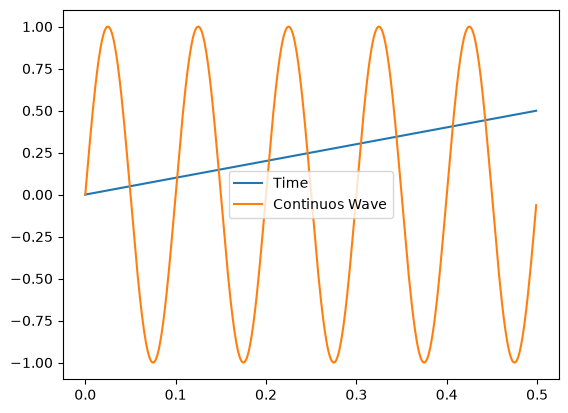

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

duration = 0.5
frequency = 10
sampling_frequency = 1000

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time)

plt.plot(time, time, label="Time")
plt.plot(time, signal, label="Continuos Wave")
plt.legend()


# Nyquist Theorem

As explained before, when we sample a signal we are taking tiny measurements of the signal at that moment in time.

But one question may come about that is, what happens if we don't sample fast enough?
Well we may get jumps in phase and end up with a signal which's frequency isn't what we hoped.

But now how does one know how fast we need to sample, how many times per second, we need to sample our signal in order to get correct measurements?

Well fortunally the **Nyquist Theorem** has the answer, it states:

$$\text{If a function }x(t) \text{ contains no frequencies higher than }B\text{ hertz, then it can be completely determined from its sampled values at a sequence of points spaced less than }\frac{1}{2B}\text{ seconds apart.}$$

Or in layman's terms to correctly sample our signal we need that $f_s \geq 2f_{max}$.

But be aware this does not mean that our signal when plotted will look "decent" only that we will be able to determin its frequency, this is shown in the code bellow.

Text(0.5, 1.0, '200Hz fs')

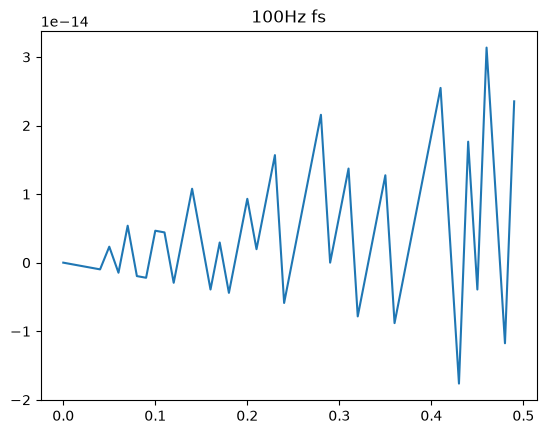

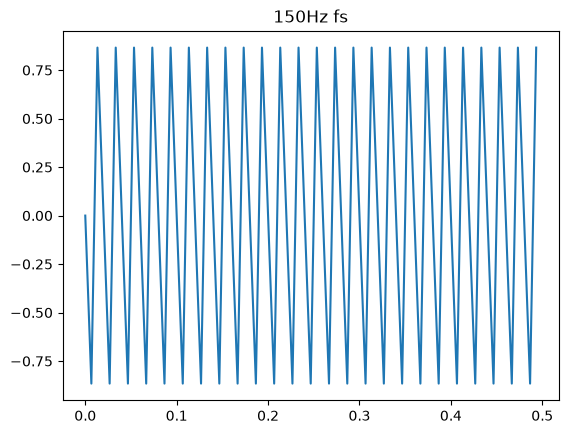

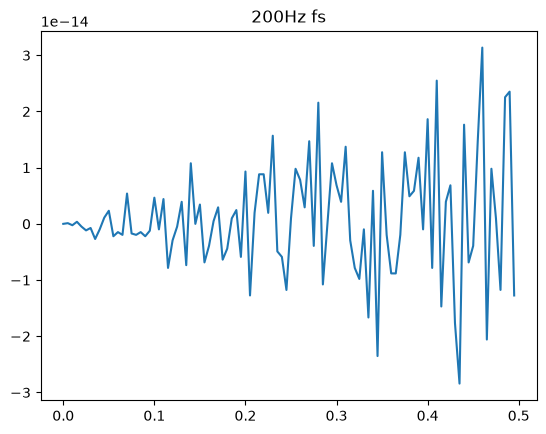

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

duration = 0.5
frequency = 100
sampling_frequency = 100

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time)

plt.figure()
plt.plot(time, signal)
plt.title("100Hz fs")

sampling_frequency = 150

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time)

plt.figure()
plt.plot(time, signal)
plt.title("150Hz fs")

sampling_frequency = 200

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time)

plt.figure()
plt.plot(time, signal)
plt.title("200Hz fs")

# Aliasing

Well now even more doubts appeared, why does the 150Hz sampled signal look "better" than the 200Hz sampled one?
This is due to a phenomenon called aliasing, this notebook won't go very in depth about it.
Aliasing happens when we dont sample the signal fast enough, we can calculate the frequency of the aliased signal.
$$
f_{alias}=|f_s-f|
$$
$$
f_{alias}=|150-100| = 50\text{Hz}
$$

Bellow is a little example showing how the 150Hz sampled signal of a 100Hz wave looks identical to a 50Hz wave, some phase shifting is normal.

Text(0.5, 1.0, '200Hz fs 50 f')

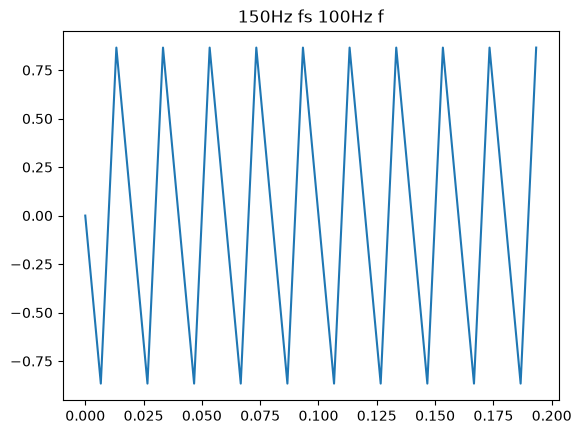

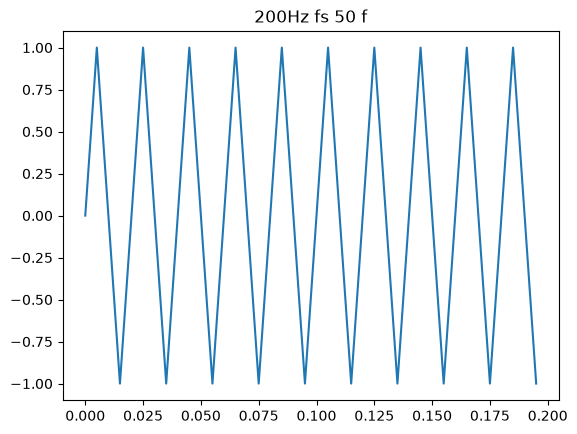

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

duration = 0.2
frequency = 100
sampling_frequency = 150

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time)

plt.figure()
plt.plot(time, signal)
plt.title("150Hz fs 100Hz f")

frequency = 50
sampling_frequency = 200

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time)

plt.figure()
plt.plot(time, signal)
plt.title("200Hz fs 50 f")

# Time VS Frequency Domain

What we just saw above is, what's called the **Time Domain**.
The **Time Domain** is just a way to show how the signal's value changes over time.

The **Frequency Domain** though is the interesting part of DSP.
Instead of showing us changes overtime, this domain shows us what **Frequency**, or frequencies, is present in our signal.

# The FFT

The **Fast Fourier Transform** (FFT) is the core of the core of the Frequency Domain.
Effectively what it does is:

> Check frequency slots and check how much of the signal is present in that slot

## Calculating the FFT

Fortunally numpy provides `np.fft.fft` a function that does all the hard FFT work.
It returns a complex array containing the one-dimensional Discrete Fourier Transform (DFT), what the DFT is is not important for now.

All we need to know is that we can check how strong a frequency is by calculating the absolute value of the complext number associated with its slot, again numpy provides `np.abs`.



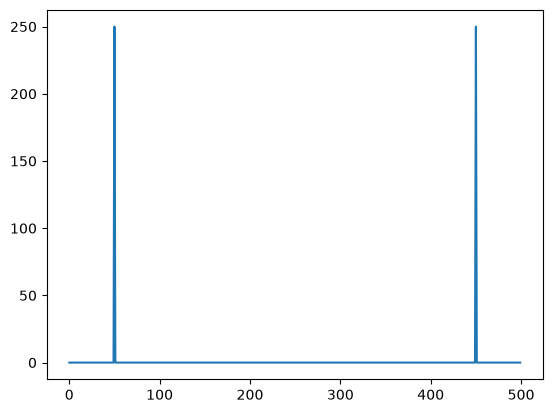

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

duration = 0.5
frequency = 100  # Lets now generate a 100Hz signal
sampling_frequency = 1000

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time)

fft = np.fft.fft(signal)
magnitude = np.abs(fft)

plt.plot(magnitude)

# Why are there two lines?

Well by the simple fact that a sine wave as both a **positive frequency** (f+) and a **negative frequency** (f-).

We can remediate this little problem by splitting the magnitude in 2.

# Why is the x axis wrong?

Well, the FFT frequency slot isn't forcefully aligned with our frequency perspective. We must align the x axis with the FFT slots. To do this, we can create another stepped array with `np.arange` and map each step to the correct frequency.

But how does one find the correct value to multiply by? Well, `np.arange` uses a step of 1 by default, meaning that it will give us the FFT bin indices:

```python
np.arange(n)
```

which produces:

```text
0, 1, 2, 3, ..., n-1
```

These values represent the **FFT bin numbers**, not the actual frequencies. To convert the bin number into a frequency, we need to know the frequency difference between two consecutive bins.

This is called the **frequency resolution**:

$$
\Delta f = \frac{f_s}{N}
$$

where:

- $f_s$ is the sampling frequency
- $N$ is the number of samples
- $\Delta f$ is the frequency difference between consecutive FFT bins.

Therefore, each bin $k$ corresponds to:

$$
f_k = k\Delta f = k\frac{f_s}{N}
$$

So we can create our frequency axis with:

```python
frequencies = np.arange(n) * (sampling_frequency / n)
```

For example, if $f_s = 1000$ Hz and $N = 1000$:

$$
\Delta f = \frac{1000}{1000}=1\text{ Hz}
$$

so the frequency axis becomes:

```text
0, 1, 2, 3, 4, ..., 999 Hz
```

Now each FFT bin is correctly mapped to its corresponding frequency.

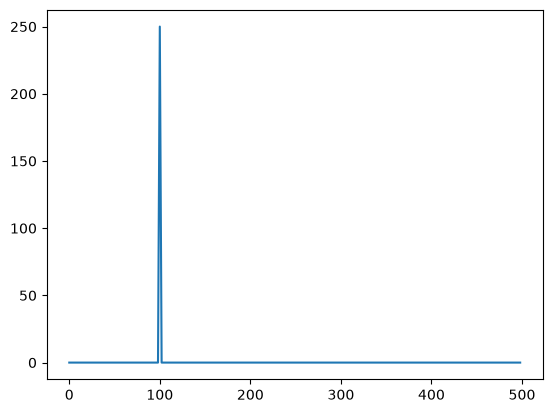

In [5]:
frequencies = np.arange(len(signal) // 2) * (sampling_frequency / len(signal))

plt.plot(frequencies, magnitude[: len(magnitude) // 2])

# Multiple Frequencies

Fortunally **numpy** makes it extremely easy for us to combine different signals into one.
In this next example you can see how 

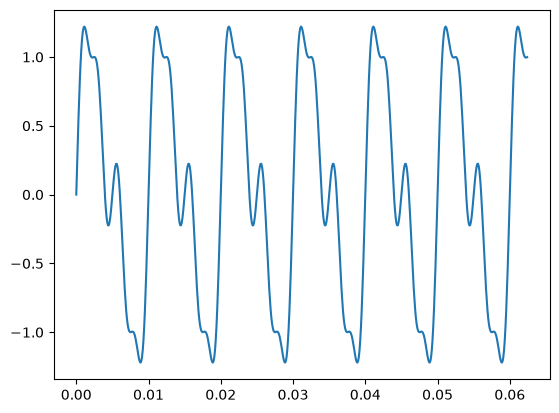

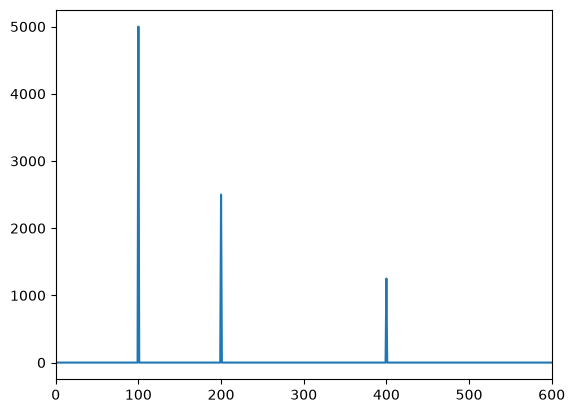

In [6]:
import numpy as np
import matplotlib.pyplot as plt

duration = 1
frequency = 100
sampling_frequency = 10000

%matplotlib inline

time = np.arange(0, duration, 1 / sampling_frequency)

signal = np.sin(2 * np.pi * frequency * time) + 0.5 * np.sin(2 * np.pi * frequency * 2 * time) + 0.25 * np.sin(2 * np.pi * frequency * 4 * time)

plt.figure()
plt.plot(time[:len(signal)//16], signal[:len(signal)//16], label="Continuos Wave") #This was scaled down as to make it eaier to see

fft = np.fft.fft(signal)
magnitude = np.abs(fft)

frequencies = np.arange(len(signal) // 2) * (sampling_frequency / len(signal))
plt.figure()
plt.xlim(0,600)
plt.plot(frequencies, magnitude[: len(magnitude) // 2])


# Spectral Leakeage